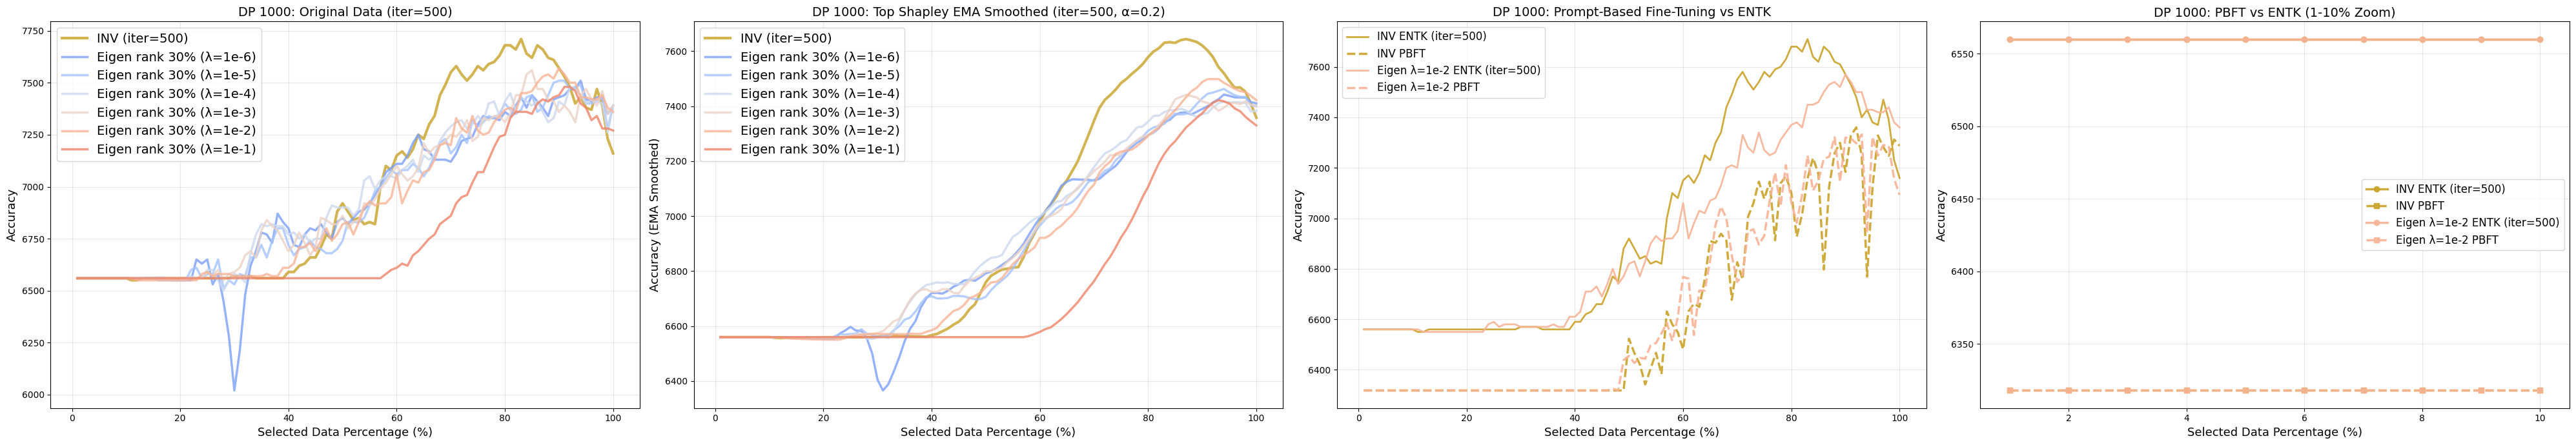

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6550, 6550, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6570, 6570, 6570, 6570, 6560, 6560, 6560, 6560, 6560, 6560, 6590, 6590, 6620, 6630, 6660, 6660, 6710, 6770, 6750, 6880, 6920, 6880, 6840, 6850, 6820, 6830, 6820, 7000, 7100, 7080, 7150, 7170, 7140, 7180, 7250, 7230, 7300, 7340, 7440, 7490, 7550, 7580, 7540, 7510, 7540, 7580, 7560, 7590, 7600, 7630, 7680, 7680, 7660, 7710, 7640, 7620, 7680, 7660, 7620, 7610, 7570, 7530, 7480, 7400, 7430, 7380, 7370, 7470, 7390, 7230, 7160]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6550, 6550, 6550, 6550, 6550, 6650, 6630, 6650, 6530, 6580, 6450, 6280, 6020, 6210, 6480, 6620, 6690, 6780, 6770, 6730, 6870, 6830, 6800, 6720, 6710, 6770, 6800, 6790, 6820, 6780, 6750, 6830, 6850, 6820, 6850, 6880, 6890, 6920, 6960, 7000, 7070, 7090, 7110, 7110, 7150, 7210, 7250, 7180, 7170, 7130, 7130, 7130, 7120, 7160, 7220, 7230, 7240, 7300, 7340, 7330, 7330, 7320, 7360, 7340, 7390, 7430, 7380, 7440, 7410, 7380, 7340, 7420, 7430, 7440, 7470, 7470, 7510, 7420, 7410, 7430, 7430, 7350, 7390]
eigen_lam1e_5    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6550, 6550, 6550, 6550, 6550, 6550, 6600, 6610, 6560, 6580, 6580, 6650, 6510, 6550, 6530, 6580, 6570, 6660, 6660, 6720, 6660, 6740, 6800, 6800, 6720, 6670, 6700, 6710, 6740, 6710, 6700, 6680, 6680, 6700, 6740, 6830, 6830, 6830, 6850, 6910, 6980, 7000, 7040, 7080, 7060, 7080, 7080, 7110, 7090, 7050, 7090, 7150, 7210, 7230, 7160, 7190, 7250, 7210, 7320, 7290, 7310, 7340, 7330, 7350, 7400, 7370, 7350, 7370, 7430, 7440, 7360, 7380, 7440, 7500, 7510, 7510, 7470, 7480, 7490, 7400, 7400, 7410, 7430, 7280, 7390]
eigen_lam1e_4    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6550, 6550, 6550, 6550, 6550, 6550, 6570, 6560, 6560, 6600, 6600, 6550, 6500, 6550, 6580, 6570, 6540, 6680, 6770, 6820, 6810, 6820, 6810, 6810, 6770, 6780, 6750, 6770, 6730, 6750, 6750, 6850, 6910, 6900, 6900, 6900, 6860, 6890, 7030, 7050, 6990, 7030, 7050, 7050, 7040, 7080, 7100, 7130, 7070, 7150, 7130, 7150, 7220, 7260, 7290, 7310, 7320, 7280, 7300, 7340, 7310, 7400, 7410, 7340, 7410, 7450, 7370, 7430, 7410, 7390, 7410, 7360, 7310, 7330, 7410, 7390, 7480, 7470, 7440, 7400, 7420, 7410, 7400, 7260, 7390]
eigen_lam1e_3    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6590, 6570, 6600, 6550, 6580, 6590, 6610, 6670, 6690, 6660, 6790, 6840, 6810, 6790, 6740, 6690, 6720, 6780, 6730, 6670, 6710, 6850, 6840, 6820, 6820, 6860, 6800, 6830, 6840, 6920, 6910, 6940, 6990, 7020, 7060, 7100, 7060, 7030, 7050, 7090, 7210, 7160, 7190, 7200, 7220, 7250, 7240, 7270, 7320, 7220, 7240, 7330, 7320, 7340, 7340, 7310, 7350, 7440, 7440, 7540, 7560, 7470, 7470, 7420, 7410, 7360, 7390, 7360, 7310, 7440, 7470, 7420, 7390, 7460, 7350, 7390]
eigen_lam1e_2    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6550, 6580, 6590, 6570, 6580, 6580, 6580, 6570, 6570, 6570, 6570, 6570, 6570, 6580, 6570, 6570, 6610, 6610, 6630, 6710, 6710, 6730, 6690, 6740, 6800, 6740, 6770, 6820, 6830, 6770, 6830, 6900, 6930, 6910, 6920, 6920, 6950, 7060, 6920, 6980, 7030, 7020, 7070, 7080, 7130, 7200, 7210, 7200, 7330, 7280, 7260, 7340, 7270, 7250, 7260, 7310, 7340, 7370, 7380, 7360, 7450, 7450, 7460, 7500, 7530, 7540, 7520, 7570, 7540, 7500, 7500, 7430, 7430, 7420, 7420, 7440, 7380, 7360]
eigen_lam1e_1    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6580, 6600, 6610, 6630, 6620, 6670, 6690, 6720, 6750, 6770, 6820, 6840, 6860, 6920, 6950, 6960, 7020, 7070, 7070, 7130, 7190, 7240, 7250, 7330, 7360, 7360, 7360, 7350, 7400, 7420, 7410, 7430, 7440, 7480, 7480, 7460, 7400, 7380, 7320, 7340, 7280, 7280, 7270]

# Prediction with random shapley values
r_inv_lam1e_6     = [5340, 5990, 6210, 6590, 6590, 6600, 6640, 6690, 6670, 6830, 6760, 6870, 6870, 6880, 6850, 7030, 6940, 6800, 6750, 6840, 6850, 6900, 6930, 6920, 6970, 6870, 6920, 6790, 6810, 6780, 6800, 6820, 6780, 6860, 6860, 6770, 6940, 6990, 6960, 6830, 6880, 6880, 6990, 6880, 6810, 6880, 6890, 6900, 6910, 7020, 7140, 7120, 7160, 7240, 7180, 7150, 7140, 7090, 7130, 7220, 7220, 7210, 7150, 7180, 7170, 7180, 7130, 7110, 7140, 7160, 7250, 7200, 7170, 7260, 7250, 7280, 7280, 7170, 7140, 7190, 7200, 7240, 7220, 7270, 7280, 7200, 7240, 7250, 7150, 7110, 7190, 7190, 7250, 7200, 7210, 7190, 7210, 7220, 7220, 7160]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = [5310, 5920, 6120, 6460, 6460, 6420, 6650, 6470, 6520, 6670, 6540, 6700, 6660, 6460, 6280, 6430, 6210, 6220, 6350, 6290, 6170, 6080, 5880, 5600, 5750, 5730, 5710, 5770, 5480, 5290, 5840, 5710, 5990, 6240, 6430, 6340, 6360, 6340, 6430, 6580, 6430, 6310, 6460, 6490, 6630, 6660, 6670, 6730, 6660, 6690, 6700, 6600, 6720, 6840, 6900, 6940, 6970, 7030, 6980, 7180, 7080, 7110, 7140, 7170, 7190, 7200, 7170, 7030, 7020, 7050, 7170, 7080, 7150, 7150, 7110, 7120, 7030, 7070, 7080, 7030, 7070, 7080, 7140, 7120, 7180, 7220, 7190, 7220, 7260, 7270, 7270, 7280, 7270, 7250, 7260, 7290, 7210, 7320, 7300, 7390]
r_eigen_lam1e_5   = [5310, 5900, 6090, 6450, 6430, 6430, 6630, 6460, 6530, 6670, 6600, 6670, 6670, 6480, 6310, 6420, 6190, 6230, 6370, 6310, 6150, 6080, 5920, 5600, 5770, 5720, 5770, 5800, 5630, 5780, 5830, 5770, 6010, 6230, 6410, 6350, 6380, 6390, 6430, 6590, 6430, 6350, 6470, 6480, 6630, 6660, 6660, 6720, 6660, 6690, 6710, 6600, 6730, 6840, 6890, 6940, 6970, 7030, 6960, 7180, 7080, 7110, 7140, 7170, 7190, 7200, 7180, 7030, 7020, 7050, 7170, 7080, 7150, 7150, 7110, 7120, 7030, 7070, 7080, 7030, 7070, 7080, 7140, 7120, 7180, 7220, 7190, 7220, 7260, 7270, 7270, 7280, 7270, 7250, 7260, 7290, 7210, 7320, 7300, 7390]
r_eigen_lam1e_4   = [5310, 5900, 6100, 6440, 6420, 6430, 6620, 6470, 6550, 6660, 6600, 6670, 6650, 6490, 6320, 6450, 6210, 6230, 6360, 6310, 6160, 6130, 5950, 5660, 5800, 6020, 5840, 5990, 6070, 6020, 5870, 5940, 6210, 6370, 6600, 6390, 6490, 6520, 6430, 6530, 6440, 6350, 6510, 6520, 6630, 6660, 6680, 6710, 6720, 6710, 6710, 6640, 6750, 6850, 6900, 6980, 6970, 7040, 6970, 7170, 7080, 7110, 7140, 7160, 7190, 7210, 7180, 7040, 7020, 7070, 7180, 7070, 7150, 7150, 7110, 7120, 7030, 7060, 7090, 7040, 7080, 7080, 7140, 7120, 7170, 7220, 7190, 7220, 7260, 7270, 7270, 7280, 7270, 7260, 7260, 7290, 7210, 7330, 7300, 7390]
r_eigen_lam1e_3   = [5310, 5920, 6090, 6430, 6420, 6400, 6630, 6510, 6570, 6660, 6580, 6670, 6630, 6570, 6380, 6530, 6330, 6400, 6410, 6430, 6380, 6280, 6230, 6040, 6350, 6400, 6310, 6470, 6500, 6410, 6490, 6460, 6560, 6570, 6650, 6730, 6720, 6760, 6720, 6610, 6660, 6540, 6530, 6690, 6620, 6770, 6710, 6760, 6690, 6720, 6780, 6780, 6910, 7000, 6960, 7050, 6990, 7020, 7020, 7170, 7080, 7120, 7150, 7180, 7200, 7210, 7170, 7060, 7070, 7110, 7160, 7100, 7160, 7190, 7150, 7150, 7030, 7100, 7120, 7060, 7090, 7090, 7170, 7110, 7170, 7210, 7190, 7230, 7270, 7280, 7310, 7280, 7280, 7270, 7290, 7290, 7230, 7330, 7300, 7390]
r_eigen_lam1e_2   = [5330, 6000, 6170, 6430, 6470, 6450, 6580, 6650, 6690, 6600, 6650, 6720, 6770, 6810, 6710, 6860, 6880, 6610, 6680, 6660, 6640, 6740, 6700, 6800, 6780, 6860, 6840, 6770, 6790, 6800, 6890, 6850, 6970, 6890, 6950, 6930, 6920, 6940, 6920, 6860, 6840, 6820, 6830, 6860, 6900, 6890, 6800, 6880, 6850, 7000, 7090, 7030, 7120, 7130, 7150, 7080, 7050, 7070, 7160, 7190, 7150, 7230, 7210, 7310, 7240, 7290, 7220, 7220, 7150, 7190, 7170, 7170, 7170, 7190, 7170, 7220, 7130, 7100, 7170, 7170, 7190, 7150, 7230, 7240, 7260, 7260, 7220, 7290, 7330, 7290, 7310, 7330, 7340, 7300, 7340, 7220, 7280, 7330, 7290, 7360]
r_eigen_lam1e_1   = [5390, 6150, 6480, 6680, 6670, 6690, 6750, 6820, 6870, 6900, 6820, 6950, 6950, 6820, 6830, 6780, 6820, 6690, 6630, 6720, 6800, 6860, 6930, 6960, 6950, 7040, 6940, 6900, 6940, 6920, 6830, 6890, 6880, 6900, 6940, 6880, 6950, 6970, 6980, 6920, 6920, 6920, 6910, 6910, 6910, 6970, 7030, 7000, 7020, 7120, 7110, 7220, 7220, 7250, 7240, 7280, 7220, 7210, 7210, 7250, 7150, 7160, 7210, 7150, 7220, 7250, 7210, 7230, 7200, 7200, 7210, 7190, 7230, 7280, 7260, 7190, 7100, 7150, 7190, 7150, 7120, 7140, 7140, 7120, 7150, 7140, 7180, 7180, 7220, 7240, 7300, 7320, 7270, 7300, 7250, 7260, 7270, 7240, 7270, 7270]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6523, 6466, 6422, 6342, 6405, 6467, 6383, 6631, 6580, 6550, 6481, 6631, 6662, 6649, 6758, 6910, 6903, 6939, 6912, 6677, 6826, 6758, 7006, 7060, 7145, 7077, 7145, 6913, 7138, 7167, 7101, 6927, 7017, 7158, 7239, 7177, 6797, 7127, 7258, 7299, 7184, 7328, 7360, 7249, 6769, 7121, 7328, 7282, 7247, 7312, 7287]
pbft_eigen_lam1e_2 = [6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6325, 6318, 6438, 6455, 6427, 6447, 6444, 6497, 6506, 6544, 6586, 6514, 6606, 6768, 6761, 6538, 6714, 6714, 6834, 6974, 7046, 7000, 6853, 6748, 6776, 6949, 6956, 6896, 6931, 7069, 7181, 7047, 7210, 7063, 6983, 7093, 7249, 7110, 7149, 7236, 7244, 7321, 7145, 7320, 7316, 7297, 7332, 6943, 7323, 7248, 7290, 7287, 7157, 7093]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): Original data =====
ax_left = axes[0]

# Plot baseline (Original)
if inv_lam1e_6 is not None:
    ax_left.plot(selected_dp_percent, inv_lam1e_6, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (Original)
for i, (data, lam_label, marker) in enumerate(lambda_configs_orig):
    ax_left.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: Original Data (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Top Shapley EMA smoothed =====
ax_middle = axes[1]

# Plot baseline (EMA)
if inv_ema is not None:
    ax_middle.plot(selected_dp_percent, inv_ema, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (EMA)
for i, (data, lam_label, marker) in enumerate(lambda_configs_ema):
    ax_middle.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy (EMA Smoothed)', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Top Shapley EMA Smoothed (iter={iteration}, α={alpha})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

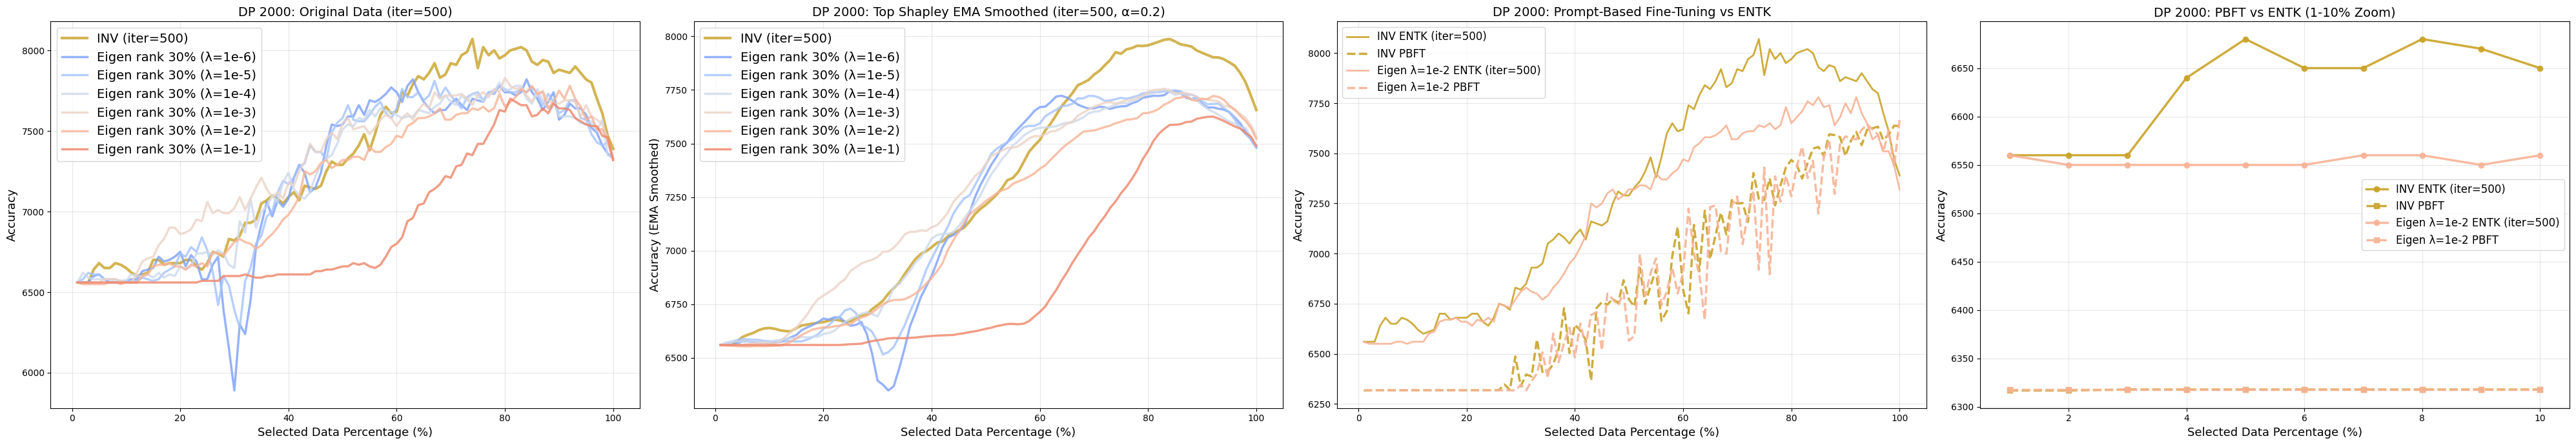

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6560, 6560, 6560, 6640, 6680, 6650, 6650, 6680, 6670, 6650, 6620, 6600, 6610, 6620, 6700, 6700, 6670, 6680, 6680, 6680, 6700, 6700, 6660, 6640, 6680, 6750, 6740, 6720, 6830, 6820, 6850, 6930, 6930, 6950, 7050, 7070, 7100, 7080, 7050, 7090, 7120, 7070, 7160, 7150, 7140, 7160, 7250, 7310, 7290, 7290, 7330, 7360, 7410, 7480, 7380, 7480, 7600, 7650, 7610, 7620, 7740, 7720, 7790, 7840, 7820, 7860, 7920, 7830, 7850, 7920, 7910, 7970, 7990, 8070, 7890, 8020, 7970, 8000, 7950, 7970, 8000, 8010, 8020, 8000, 7930, 7910, 7940, 7930, 7860, 7880, 7870, 7860, 7900, 7860, 7820, 7800, 7700, 7610, 7470, 7390]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = [6560, 6560, 6560, 6600, 6610, 6580, 6560, 6560, 6570, 6570, 6580, 6580, 6630, 6640, 6650, 6720, 6690, 6700, 6720, 6750, 6660, 6730, 6690, 6580, 6580, 6670, 6720, 6390, 6150, 5890, 6300, 6240, 6450, 6780, 6920, 7060, 6970, 7070, 7030, 7080, 7210, 7290, 7240, 7120, 7150, 7240, 7410, 7540, 7530, 7540, 7590, 7590, 7660, 7600, 7690, 7680, 7700, 7730, 7770, 7740, 7680, 7780, 7820, 7740, 7680, 7640, 7610, 7630, 7630, 7670, 7700, 7660, 7630, 7700, 7690, 7680, 7740, 7730, 7780, 7740, 7740, 7720, 7740, 7820, 7740, 7700, 7630, 7680, 7740, 7570, 7600, 7670, 7640, 7640, 7600, 7520, 7490, 7410, 7360, 7330]
eigen_lam1e_5    = [6560, 6580, 6620, 6610, 6610, 6580, 6580, 6580, 6560, 6570, 6570, 6570, 6590, 6580, 6570, 6580, 6620, 6640, 6660, 6740, 6720, 6780, 6750, 6840, 6760, 6630, 6420, 6600, 6540, 6390, 6280, 6570, 6650, 6800, 6850, 6970, 7000, 7120, 7190, 7170, 7210, 7280, 7300, 7410, 7370, 7370, 7320, 7490, 7550, 7580, 7660, 7570, 7560, 7560, 7600, 7650, 7680, 7610, 7580, 7640, 7760, 7710, 7710, 7740, 7690, 7720, 7810, 7710, 7770, 7720, 7680, 7640, 7710, 7730, 7740, 7690, 7740, 7750, 7780, 7760, 7740, 7740, 7760, 7740, 7770, 7730, 7660, 7730, 7680, 7610, 7630, 7690, 7690, 7580, 7570, 7480, 7430, 7410, 7430, 7330]
eigen_lam1e_4    = [6560, 6620, 6590, 6580, 6580, 6580, 6580, 6560, 6570, 6570, 6610, 6600, 6600, 6610, 6590, 6620, 6590, 6610, 6600, 6660, 6640, 6660, 6740, 6740, 6750, 6730, 6760, 6740, 6670, 6650, 6940, 6870, 7080, 6900, 7000, 7030, 7100, 7060, 7180, 7240, 7140, 7100, 7080, 7120, 7220, 7290, 7330, 7350, 7420, 7510, 7540, 7530, 7580, 7570, 7630, 7590, 7640, 7620, 7620, 7600, 7580, 7590, 7590, 7630, 7620, 7610, 7650, 7670, 7720, 7680, 7660, 7720, 7690, 7730, 7720, 7680, 7730, 7740, 7800, 7750, 7760, 7780, 7780, 7700, 7670, 7760, 7690, 7640, 7680, 7590, 7590, 7590, 7580, 7550, 7540, 7560, 7500, 7570, 7350, 7330]
eigen_lam1e_3    = [6560, 6560, 6560, 6560, 6560, 6580, 6580, 6580, 6570, 6560, 6560, 6620, 6690, 6710, 6720, 6790, 6830, 6900, 6900, 6860, 6870, 6890, 6950, 6940, 7060, 6990, 7010, 6990, 6990, 7020, 7090, 7010, 7080, 7150, 7210, 7140, 7090, 7120, 7080, 7180, 7160, 7250, 7310, 7420, 7370, 7370, 7450, 7490, 7450, 7550, 7580, 7510, 7520, 7530, 7480, 7520, 7570, 7600, 7580, 7530, 7580, 7610, 7570, 7630, 7670, 7640, 7740, 7700, 7720, 7720, 7720, 7730, 7700, 7660, 7720, 7740, 7710, 7760, 7740, 7830, 7780, 7760, 7770, 7720, 7680, 7730, 7750, 7690, 7670, 7670, 7690, 7690, 7680, 7590, 7660, 7590, 7570, 7540, 7450, 7330]
eigen_lam1e_2    = [6560, 6550, 6550, 6550, 6550, 6550, 6560, 6560, 6550, 6560, 6560, 6560, 6600, 6610, 6660, 6670, 6670, 6680, 6660, 6660, 6640, 6670, 6660, 6680, 6660, 6750, 6740, 6730, 6770, 6810, 6830, 6810, 6800, 6770, 6790, 6830, 6860, 6900, 6950, 6980, 7030, 7090, 7250, 7230, 7250, 7300, 7320, 7270, 7290, 7320, 7320, 7340, 7340, 7320, 7400, 7370, 7370, 7400, 7420, 7470, 7460, 7530, 7550, 7580, 7580, 7590, 7610, 7640, 7570, 7570, 7600, 7610, 7610, 7640, 7630, 7650, 7620, 7640, 7730, 7650, 7680, 7710, 7760, 7740, 7780, 7730, 7740, 7640, 7680, 7750, 7700, 7780, 7700, 7650, 7570, 7590, 7510, 7510, 7440, 7320]
eigen_lam1e_1    = [6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6560, 6570, 6570, 6570, 6570, 6600, 6600, 6600, 6600, 6610, 6600, 6590, 6590, 6600, 6600, 6610, 6610, 6610, 6610, 6610, 6610, 6610, 6630, 6630, 6640, 6640, 6650, 6660, 6660, 6680, 6670, 6680, 6660, 6650, 6670, 6720, 6780, 6800, 6840, 6940, 6960, 7040, 7050, 7120, 7140, 7170, 7220, 7210, 7280, 7290, 7360, 7350, 7420, 7420, 7480, 7540, 7630, 7620, 7700, 7680, 7660, 7660, 7590, 7600, 7640, 7610, 7670, 7640, 7640, 7630, 7580, 7560, 7540, 7530, 7530, 7470, 7460, 7320]

# Prediction with random shapley values
r_inv_lam1e_6     = [4650, 6070, 6300, 6660, 6530, 6720, 6660, 6700, 6580, 6460, 6470, 6440, 6330, 6540, 6640, 6760, 6780, 6670, 6720, 6810, 6760, 6730, 6820, 6800, 6850, 6790, 6730, 6680, 6630, 6730, 6830, 6770, 6720, 6750, 6680, 6830, 6720, 6790, 6750, 6780, 6720, 6790, 6710, 6750, 6810, 6880, 6930, 6950, 6900, 6840, 6830, 6910, 6970, 6940, 6980, 7010, 7030, 7080, 7040, 7030, 7070, 7040, 7010, 7170, 7080, 7150, 7220, 7220, 7210, 7210, 7110, 7170, 7150, 7160, 7280, 7310, 7310, 7410, 7330, 7370, 7330, 7420, 7340, 7380, 7260, 7290, 7330, 7360, 7370, 7380, 7450, 7470, 7430, 7390, 7400, 7390, 7360, 7410, 7340, 7390]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = [4690, 6010, 6220, 6440, 6400, 6260, 6260, 6040, 5970, 5830, 5750, 5600, 5430, 5650, 5540, 5700, 5530, 5530, 5590, 5540, 5490, 5540, 5470, 5440, 5430, 5370, 5520, 5680, 5590, 5200, 5410, 5600, 5560, 5630, 5590, 5710, 5600, 5600, 5780, 5940, 6090, 5940, 6010, 6230, 6140, 6180, 6270, 6290, 6300, 6240, 6440, 6470, 6490, 6460, 6610, 6580, 6660, 6700, 6770, 6790, 6900, 6910, 6920, 6950, 7010, 7080, 7040, 7120, 7080, 7110, 7180, 7120, 7210, 7250, 7310, 7260, 7170, 7240, 7260, 7240, 7210, 7250, 7210, 7250, 7280, 7220, 7320, 7250, 7260, 7250, 7220, 7260, 7250, 7290, 7290, 7270, 7300, 7320, 7360, 7330]
r_eigen_lam1e_5   = [4680, 6020, 6220, 6450, 6370, 6280, 6290, 6070, 5950, 5820, 5710, 5550, 5420, 5650, 5550, 5660, 5510, 5520, 5590, 5520, 5490, 5550, 5460, 5430, 5460, 5380, 5530, 5740, 5640, 5680, 5500, 5690, 5560, 5670, 5670, 5690, 5630, 5610, 5790, 5930, 6100, 5940, 6020, 6240, 6150, 6180, 6280, 6280, 6300, 6240, 6440, 6470, 6490, 6460, 6610, 6580, 6670, 6700, 6770, 6800, 6900, 6910, 6920, 6950, 7010, 7080, 7040, 7120, 7080, 7110, 7180, 7120, 7210, 7250, 7310, 7260, 7170, 7240, 7260, 7240, 7210, 7250, 7210, 7260, 7280, 7220, 7320, 7250, 7260, 7250, 7220, 7260, 7250, 7290, 7290, 7270, 7300, 7320, 7360, 7330]
r_eigen_lam1e_4   = [4690, 6000, 6230, 6440, 6370, 6280, 6290, 6080, 5960, 5830, 5710, 5580, 5440, 5650, 5560, 5700, 5550, 5530, 5670, 5550, 5520, 5540, 5440, 5510, 5570, 5510, 5630, 5690, 5690, 5810, 5680, 5870, 5710, 5730, 5830, 5790, 5750, 5700, 5860, 6000, 6130, 5920, 6120, 6250, 6210, 6190, 6300, 6320, 6290, 6280, 6430, 6470, 6520, 6460, 6630, 6600, 6680, 6710, 6780, 6800, 6880, 6890, 6940, 6950, 7030, 7090, 7040, 7120, 7080, 7140, 7160, 7120, 7220, 7250, 7310, 7250, 7170, 7240, 7250, 7230, 7200, 7250, 7210, 7260, 7280, 7230, 7300, 7250, 7260, 7250, 7210, 7260, 7250, 7290, 7290, 7270, 7300, 7320, 7360, 7330]
r_eigen_lam1e_3   = [4680, 6000, 6210, 6480, 6380, 6310, 6350, 6230, 6090, 5940, 5750, 5680, 5520, 5730, 5710, 5900, 5870, 5730, 5830, 5720, 5730, 5680, 5740, 5710, 5860, 5870, 5900, 6050, 5980, 5990, 6030, 6090, 5930, 6060, 6150, 6130, 6120, 6030, 6100, 6180, 6220, 6170, 6260, 6440, 6370, 6350, 6400, 6360, 6440, 6400, 6490, 6470, 6560, 6540, 6700, 6660, 6800, 6670, 6880, 6820, 6900, 6960, 6980, 7040, 7030, 7130, 7060, 7140, 7110, 7140, 7140, 7160, 7230, 7290, 7300, 7250, 7200, 7260, 7260, 7240, 7220, 7240, 7240, 7250, 7270, 7230, 7310, 7260, 7290, 7250, 7210, 7270, 7260, 7270, 7270, 7280, 7300, 7320, 7350, 7330]
r_eigen_lam1e_2   = [4660, 6010, 6200, 6510, 6550, 6590, 6680, 6520, 6430, 6420, 6270, 6290, 6230, 6280, 6400, 6470, 6430, 6290, 6410, 6390, 6380, 6410, 6470, 6470, 6450, 6350, 6450, 6430, 6360, 6460, 6570, 6600, 6470, 6540, 6500, 6570, 6620, 6560, 6680, 6690, 6660, 6600, 6690, 6780, 6710, 6740, 6770, 6880, 6850, 6920, 6950, 6940, 6860, 6920, 6950, 6910, 6980, 7030, 7140, 7080, 7140, 7190, 7180, 7190, 7160, 7200, 7210, 7190, 7190, 7300, 7190, 7260, 7330, 7330, 7340, 7330, 7230, 7330, 7280, 7250, 7290, 7260, 7310, 7250, 7240, 7220, 7270, 7240, 7260, 7240, 7280, 7340, 7290, 7250, 7280, 7320, 7310, 7320, 7360, 7320]
r_eigen_lam1e_1   = [4410, 6210, 6460, 6660, 6730, 6870, 6710, 6680, 6600, 6630, 6700, 6610, 6680, 6770, 6780, 6910, 6880, 6860, 6960, 6990, 6840, 6900, 6930, 6950, 7000, 7020, 7030, 7050, 6980, 6990, 7080, 7050, 7150, 7080, 7080, 7090, 7100, 7170, 7120, 7020, 7140, 7080, 7060, 7080, 7040, 7100, 7150, 7190, 7200, 7150, 7230, 7190, 7170, 7200, 7220, 7240, 7240, 7270, 7240, 7250, 7300, 7320, 7240, 7320, 7270, 7280, 7340, 7350, 7340, 7360, 7370, 7340, 7400, 7270, 7340, 7350, 7300, 7320, 7250, 7310, 7280, 7290, 7300, 7290, 7260, 7260, 7300, 7300, 7300, 7250, 7300, 7290, 7320, 7340, 7320, 7330, 7310, 7330, 7390, 7320]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6317, 6317, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6320, 6347, 6320, 6487, 6338, 6397, 6387, 6572, 6410, 6412, 6448, 6524, 6728, 6504, 6645, 6616, 6569, 6366, 6728, 6758, 6745, 6774, 6753, 6867, 6771, 6736, 6929, 6749, 6840, 6921, 6665, 6713, 6988, 7133, 6820, 6702, 7143, 6911, 7214, 6972, 7093, 7204, 7095, 7267, 7250, 7252, 7158, 7402, 7273, 7267, 7375, 7240, 7340, 7430, 7467, 7442, 7374, 7450, 7524, 7532, 7488, 7595, 7591, 7581, 7487, 7562, 7607, 7541, 7617, 7625, 7633, 7566, 7594, 7638, 7636]
pbft_eigen_lam1e_2 = [6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6318, 6346, 6318, 6363, 6403, 6507, 6378, 6601, 6458, 6554, 6630, 6482, 6651, 6541, 6693, 6708, 6517, 6800, 6772, 6742, 6805, 6565, 6590, 6997, 6789, 6904, 6976, 6743, 6811, 6931, 6801, 6903, 7224, 7000, 6895, 6670, 7232, 7240, 7011, 6999, 7240, 7285, 7047, 7202, 7315, 6920, 7429, 6897, 7385, 7258, 7388, 7286, 7433, 7534, 7377, 7463, 7199, 7479, 7568, 7298, 7546, 7585, 7573, 7570, 7617, 7645, 7619, 7594, 7508, 7615, 7433, 7667]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): Original data =====
ax_left = axes[0]

# Plot baseline (Original)
if inv_lam1e_6 is not None:
    ax_left.plot(selected_dp_percent, inv_lam1e_6, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (Original)
for i, (data, lam_label, marker) in enumerate(lambda_configs_orig):
    ax_left.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: Original Data (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Top Shapley EMA smoothed =====
ax_middle = axes[1]

# Plot baseline (EMA)
if inv_ema is not None:
    ax_middle.plot(selected_dp_percent, inv_ema, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (EMA)
for i, (data, lam_label, marker) in enumerate(lambda_configs_ema):
    ax_middle.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy (EMA Smoothed)', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Top Shapley EMA Smoothed (iter={iteration}, α={alpha})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = 
eigen_lam1e_5    = 
eigen_lam1e_4    = 
eigen_lam1e_3    = 
eigen_lam1e_2    = 
eigen_lam1e_1    = 

# Prediction with random shapley values
r_inv_lam1e_6     = 
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = 
r_eigen_lam1e_5   = 
r_eigen_lam1e_4   = 
r_eigen_lam1e_3   = 
r_eigen_lam1e_2   = 
r_eigen_lam1e_1   = 

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = 
pbft_eigen_lam1e_2 = 

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): Original data =====
ax_left = axes[0]

# Plot baseline (Original)
if inv_lam1e_6 is not None:
    ax_left.plot(selected_dp_percent, inv_lam1e_6, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (Original)
for i, (data, lam_label, marker) in enumerate(lambda_configs_orig):
    ax_left.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: Original Data (iter={iteration})', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Top Shapley EMA smoothed =====
ax_middle = axes[1]

# Plot baseline (EMA)
if inv_ema is not None:
    ax_middle.plot(selected_dp_percent, inv_ema, 
             color=inv_color, linewidth=3, linestyle='-', 
             label=f'INV (iter={iteration})', alpha=0.8)

# Plot eigen with different lambda values (EMA)
for i, (data, lam_label, marker) in enumerate(lambda_configs_ema):
    ax_middle.plot(selected_dp_percent, data, 
             color=colors[i], linewidth=2.5, linestyle='-', 
             label=f'Eigen rank {rank}% (λ={lam_label})', alpha=0.8)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy (EMA Smoothed)', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Top Shapley EMA Smoothed (iter={iteration}, α={alpha})', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

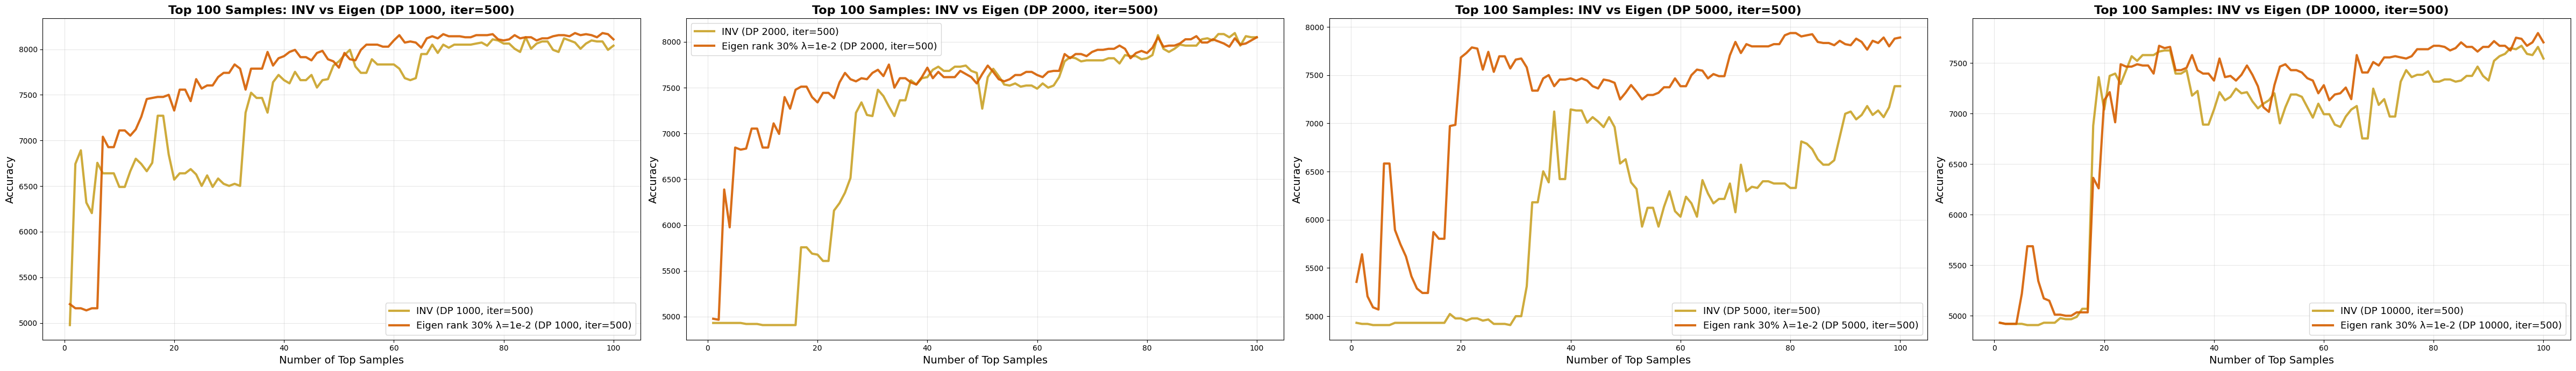

In [ ]:
# top 100 data
data = [i for i in range(1, 101)]
inv_1000              = 
eigen_1000_30_lam1e_2 = 

inv_2000              = 
eigen_2000_30_lam1e_2 = 

inv_5000              = 
eigen_5000_30_lam1e_2 = 

inv_10000              = 
eigen_10000_30_lam1e_2 = 

# Create (1,4) subplots
fig, axes = plt.subplots(1, 4, figsize=(48, 7))

# Color settings
inv_color = '#C9A227'
eigen_color = '#D55E00'  # Orange-red for eigen

# ===== Subplot (1,1): DP 1000 =====
ax_1000 = axes[0]

# Plot INV data (num_dp=1000)
ax_1000.plot(data, inv_1000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 1000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=1000, rank=30%, lambda=1e-2)
ax_1000.plot(data, eigen_1000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 1000, iter=500)', alpha=0.9)

ax_1000.set_xlabel('Number of Top Samples', fontsize=14)
ax_1000.set_ylabel('Accuracy', fontsize=14)
ax_1000.set_title('Top 100 Samples: INV vs Eigen (DP 1000, iter=500)', fontsize=16, fontweight='bold')
ax_1000.legend(fontsize=13, loc='best')
ax_1000.grid(True, alpha=0.3)

# ===== Subplot (1,2): DP 2000 =====
ax_2000 = axes[1]

# Plot INV data (num_dp=2000)
ax_2000.plot(data, inv_2000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2000, rank=30%, lambda=1e-2)
ax_2000.plot(data, eigen_2000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2000, iter=500)', alpha=0.9)

ax_2000.set_xlabel('Number of Top Samples', fontsize=14)
ax_2000.set_ylabel('Accuracy', fontsize=14)
ax_2000.set_title('Top 100 Samples: INV vs Eigen (DP 2000, iter=500)', fontsize=16, fontweight='bold')
ax_2000.legend(fontsize=13, loc='best')
ax_2000.grid(True, alpha=0.3)

# ===== Subplot (1,3): DP 5000 =====
ax_5000 = axes[2]

# Plot INV data (num_dp=5000)
ax_5000.plot(data, inv_5000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 5000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=5000, rank=30%, lambda=1e-2)
ax_5000.plot(data, eigen_5000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 5000, iter=500)', alpha=0.9)

ax_5000.set_xlabel('Number of Top Samples', fontsize=14)
ax_5000.set_ylabel('Accuracy', fontsize=14)
ax_5000.set_title('Top 100 Samples: INV vs Eigen (DP 5000, iter=500)', fontsize=16, fontweight='bold')
ax_5000.legend(fontsize=13, loc='best')
ax_5000.grid(True, alpha=0.3)

# ===== Subplot (1,4): DP 10000 =====
ax_10000 = axes[3]

# Plot INV data (num_dp=10000)
ax_10000.plot(data, inv_10000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 10000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=10000, rank=30%, lambda=1e-2)
ax_10000.plot(data, eigen_10000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 10000, iter=500)', alpha=0.9)

ax_10000.set_xlabel('Number of Top Samples', fontsize=14)
ax_10000.set_ylabel('Accuracy', fontsize=14)
ax_10000.set_title('Top 100 Samples: INV vs Eigen (DP 10000, iter=500)', fontsize=16, fontweight='bold')
ax_10000.legend(fontsize=13, loc='best')
ax_10000.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()